In [ ]:
# Generate a dummy dataframes for testing purposes


In [ ]:
# Read a PT file


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# Load the .pt file
image_tensor = torch.load('../data/input_image.pt')

entropy_tensor = torch.load('../data/entropy.pt')

image_array = image_tensor.numpy()
entropy_array = entropy_tensor.numpy()

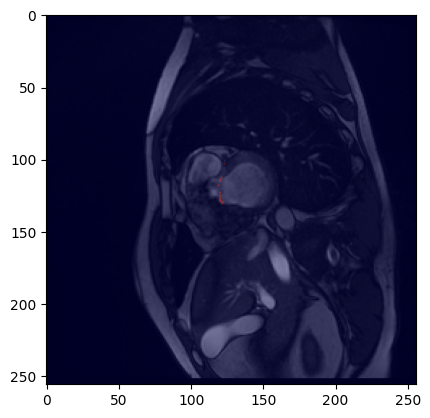

In [2]:
# Overlay the image with the entropy
def threshold_and_overlay(threshold ,image = image_array, entropy= entropy_array):
    thresholded_entropy = np.where(entropy > threshold, entropy, 0)
    plt.imshow(image, cmap='gray')
    plt.imshow(thresholded_entropy, cmap='seismic', alpha=0.5)
    plt.show()


threshold_and_overlay(0.9)

In [40]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def overlay_with_threshold(overlay_image, threshold=None, percentile=98):
    
    # Determine threshold
    if threshold is None:
        threshold = np.percentile(overlay_image, percentile)  # Automatically compute threshold
    
    # Normalize overlay image
    norm = mcolors.Normalize(vmin=np.min(overlay_image), vmax=np.max(overlay_image))
    
    # Get the seismic colormap
    cmap = cm.get_cmap('seismic')
    
    # Apply colormap to the normalized overlay image
    overlay_rgba = cmap(norm(overlay_image))  # Converts to RGBA

    # Make values below the threshold transparent
    overlay_rgba[overlay_image < threshold, 3] = 0  # Set alpha to 0 for values below threshold

    return overlay_rgba

C:\Users\Youssef Shawki\AppData\Local\Temp\ipykernel_14968\1313933399.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic')


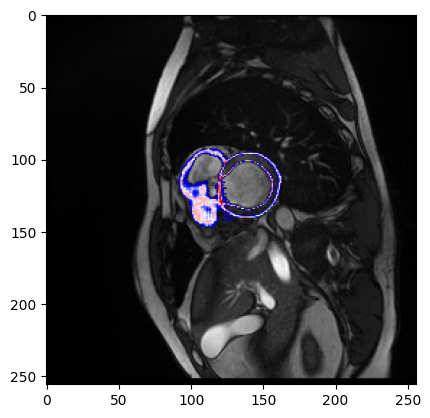

In [41]:
overlay_image = overlay_with_threshold(entropy_array)

plt.imshow(image_array, cmap='gray')
plt.imshow(overlay_image)
plt.show()

C:\Users\Youssef Shawki\AppData\Local\Temp\ipykernel_14968\1811912839.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('seismic')


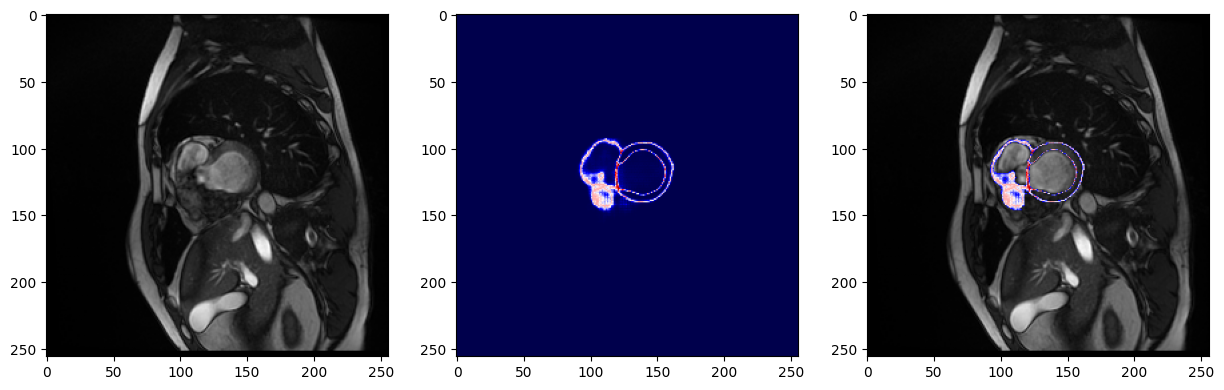

In [18]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from skimage.filters import threshold_otsu

overlay_image = entropy_array


# plt.imshow(image_array, cmap='gray')
# Normalize overlay image
# Compute Otsu's threshold
otsu_threshold = threshold_otsu(overlay_image)

# Normalize overlay image
norm = mcolors.Normalize(vmin=np.min(overlay_image), vmax=np.max(overlay_image))

# Get the seismic colormap
cmap = cm.get_cmap('seismic')

# Apply colormap to the normalized overlay image
overlay_rgba = cmap(norm(overlay_image))  # Converts to RGBA

# Make values below Otsu's threshold transparent
overlay_rgba[overlay_image < otsu_threshold, 3] = 0  # Set alpha to 0 for low entropy values

fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax[0].imshow(image_array, cmap='gray')
ax[1].imshow(entropy_array, cmap='seismic')

# Overlay image_array with overlay_rgba
ax[2].imshow(image_array, cmap='gray')
ax[2].imshow(overlay_rgba)
plt.show()



In [10]:
# get unique values in the entropy array and sort them in ascending order
unique_entropy_values = np.unique(entropy_array)
unique_entropy_values = np.sort(unique_entropy_values)

for i in range(len(unique_entropy_values)):
    print(f"Threshold: {unique_entropy_values[i]}")

Threshold: 1.9569802134355996e-06
Threshold: 2.3600164240633603e-06
Threshold: 3.0966898521000985e-06
Threshold: 4.121387064515147e-06
Threshold: 4.411998816067353e-06
Threshold: 5.632723514281679e-06
Threshold: 6.494748959084973e-06
Threshold: 7.213438038888853e-06
Threshold: 7.397621175186941e-06
Threshold: 7.445558367180638e-06
Threshold: 7.743000423943158e-06
Threshold: 8.225219062296674e-06
Threshold: 8.311264537042007e-06
Threshold: 8.58157090988243e-06
Threshold: 8.828081263345666e-06
Threshold: 8.93863762030378e-06
Threshold: 9.06119112187298e-06
Threshold: 9.165033588942606e-06
Threshold: 9.412588042323478e-06
Threshold: 9.475823389948346e-06
Threshold: 9.479041182203218e-06
Threshold: 9.64829814620316e-06
Threshold: 9.795978257898241e-06
Threshold: 9.848109584709164e-06
Threshold: 9.890359251585323e-06
Threshold: 9.93424873740878e-06
Threshold: 9.991525075747631e-06
Threshold: 1.0039500011771452e-05
Threshold: 1.0079525964101776e-05
Threshold: 1.023646655085031e-05
Threshold:

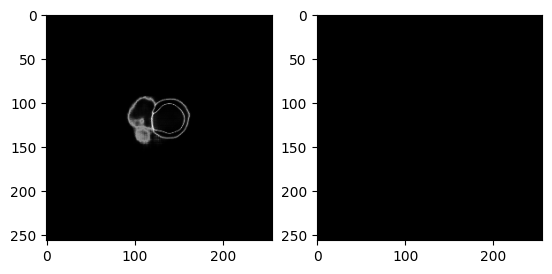

In [121]:
# keep only the high entropy regions

threshold = 2.0
mask = entropy_array > threshold
filtered_entropy = mask * entropy_array

fig, ax = plt.subplots(1, 2)
ax[0].imshow(entropy_array, cmap='gray')
ax[1].imshow(filtered_entropy, cmap='gray')
plt.show()


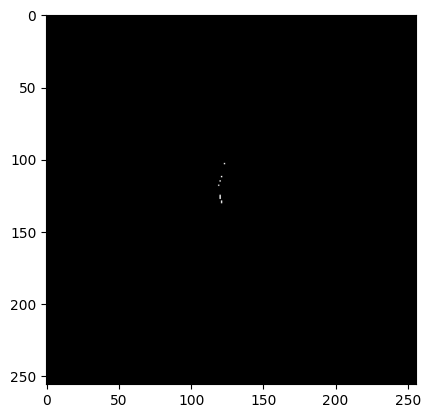

In [123]:
img = np.where(entropy_array > 1.0, entropy_array, 0)
plt.imshow(img, cmap='gray')

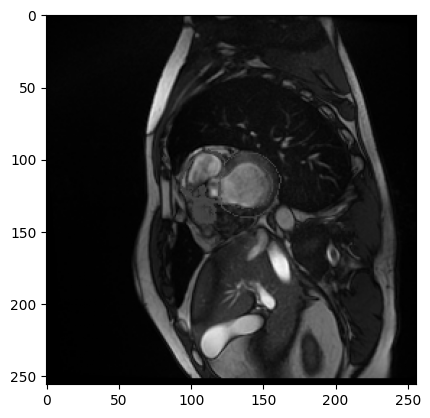

In [124]:
res = np.where(entropy_array > 0.5, entropy_array, image_array)
plt.imshow(res, cmap='gray')
plt.show()

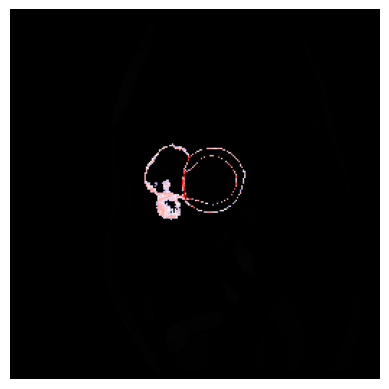

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm



# Normalize entropy array for colormap mapping
norm_entropy = (entropy_array - entropy_array.min()) / (entropy_array.max() - entropy_array.min())

# Create a mask
mask = entropy_array > 0.5

# Convert to colormaps
seismic_mapped = cm.seismic(norm_entropy)  # RGBA (0-1 range)
gray_mapped = cm.gray(image_array / 255)   # Normalize image_array and apply grayscale

# Combine: Use seismic where mask is True, otherwise use gray
colored_output = np.where(mask[..., None], seismic_mapped, gray_mapped)

# Display the image
plt.imshow(colored_output)
plt.axis('off')
plt.show()


In [131]:
image_array.max()

np.float32(4.5043225)

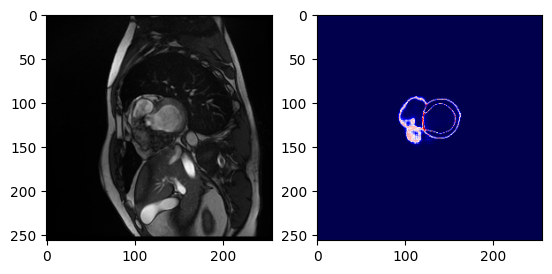

In [ ]:
# Plot image and entropy side by side
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image_array, cmap='gray')
ax[1].imshow(entropy_array, cmap='seismic')
plt.show()

## Dataframe

In [1]:
import pandas as pd

df = pd.read_csv('../dataframe.csv')
df.head()

,batch_index,image_index,avg_error,avg_entropy
0,9,24,0.404800,0.049940
1,9,23,0.397461,0.052719
2,9,26,0.366791,0.050594
3,9,25,0.358978,0.043790
4,9,27,0.352875,0.037998


In [23]:
if(0.1 > 0) :
    print("True")

True


In [12]:
row = df.iloc[0]
row['batch_index']

np.float64(9.0)

In [31]:
df_2 = pd.DataFrame()
df_2['Error'] = None


df.iloc[0, 0]

np.int64(9)

In [32]:
df = pd.concat([df_2, df], axis=1)

In [40]:


# Check for NaN values
bool(df.iloc[0].isna()['image_index'])

False

In [43]:
df['Error'][2]

nan

In [9]:
pd.concat([df, df_2], ignore_index=True)

,batch_index,image_index,avg_error,avg_entropy,Error
0,9.0,24.0,0.404800,0.049940,NaN
1,9.0,23.0,0.397461,0.052719,NaN
2,9.0,26.0,0.366791,0.050594,NaN
3,9.0,25.0,0.358978,0.043790,NaN
4,9.0,27.0,0.352875,0.037998,NaN
...,...,...,...,...,...
1271,1.0,12.0,0.000000,0.002195,NaN
1272,39.0,10.0,0.000000,0.002237,NaN
1273,0.0,13.0,0.000000,0.001615,NaN
1274,0.0,0.0,0.000000,0.002412,NaN


In [6]:
int(df.iloc[0]['batch_index'])

9

In [8]:
# get image of batch 9 and image 24 from dataframe
batch_index = 9
image_index = 24


result = df[(df["batch_index"] == batch_index) & (df["image_index"] == image_index)]

In [12]:
result['avg_entropy'].values[0]

np.float64(0.0499401055)

In [ ]:
# sort the dataframe by ascending entropy
df_sorted = df.sort_values(by='entropy', ascending=True)

In [16]:
type([(3,4)][0])

tuple

In [2]:
# Compare time of looking up a row in dataframe by index and by value
import time

batch_index = 9
image_index = 24

start = time.time()
result = df[(df["batch_index"] == batch_index) & (df["image_index"] == image_index)]
print(time.time() - start)

start = time.time()
result = df.loc[(df["batch_index"] == batch_index) & (df["image_index"] == image_index)]
print(time.time() - start)



0.004514932632446289
0.0


In [5]:
# get row at index 1150
row = df.iloc[1150]
row

batch_index    15.00000
image_index    31.00000
avg_error       0.00000
avg_entropy     0.00093
Name: 1150, dtype: float64

In [11]:
x = [1]
bool(x)

True

In [45]:
x = None
if x == None:
    print('True')

True
